# Chapter 4 Application

## Installing Packages

In [1]:
!pip install uv && uv pip install ISLP
import ISLP
print(ISLP.__version__)

path = "/content/drive/Othercomputers/My MacBook Pro/Professional Development/Data Science/ISLP/ISLP/"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 50.1 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 56 packages in 5.16s
Prepared 9 packages in 1.33s
Installed 9 packages in 68ms
 + autograd-gamma==0.5.0
 + formulaic==1.2.2
 + interface-meta==2.0.1
 + islp==0.4.1
 + lifelines==0.30.3
 + lightning-utilities==0.15.3
 + pygam==0.12.0
 + pytorch-lightning==2.6.5
 + torchmetrics==1.9.0
0.4.1


In [55]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)
from ISLP import confusion_table
from ISLP.models import contrast

from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error

## 13. Weekly Data Set

### a) EDA

In [3]:
Weekly = load_data('Weekly')
Weekly['Direction'] = Weekly['Direction'].map({'Down': 0, 'Up': 1})

Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,1
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,1
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,1
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,1
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,1


In [4]:
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


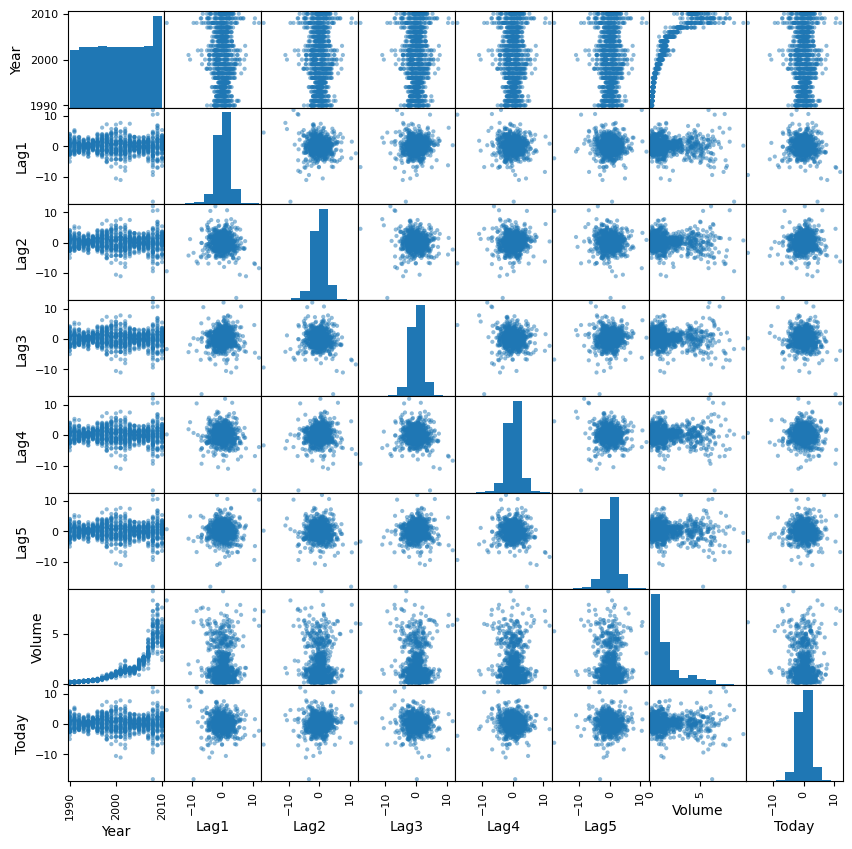

In [5]:
pd.plotting.scatter_matrix(Weekly, figsize=(10,10));

<Axes: >

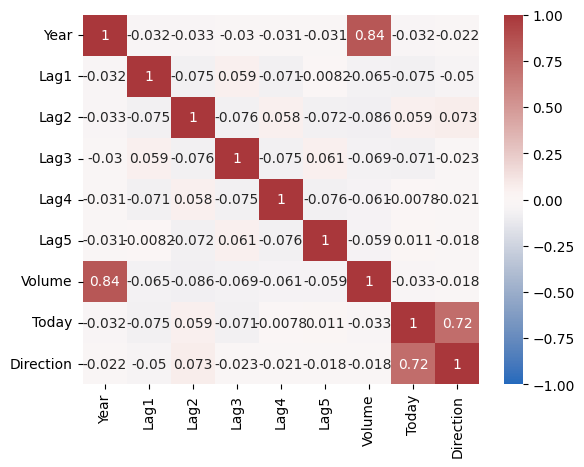

In [6]:
corr_m = Weekly.corr()
sns.heatmap(corr_m, cmap='vlag', annot=True, vmin=-1, vmax=1)

- Lag1-Lag5 are not correlated with each other and have very weak association.
- Year and Volume are positively correlated.
- Lags x Year and Lags x Volume have no trend or correlation.
- No clear relationship between any of the variables and Today's return.

### b) Log Reg

In [7]:
X = Weekly.drop(columns=['Today', 'Direction', 'Year'])
y = Weekly['Direction']
X, y

(       Lag1   Lag2   Lag3   Lag4   Lag5    Volume
 0     0.816  1.572 -3.936 -0.229 -3.484  0.154976
 1    -0.270  0.816  1.572 -3.936 -0.229  0.148574
 2    -2.576 -0.270  0.816  1.572 -3.936  0.159837
 3     3.514 -2.576 -0.270  0.816  1.572  0.161630
 4     0.712  3.514 -2.576 -0.270  0.816  0.153728
 ...     ...    ...    ...    ...    ...       ...
 1084 -0.861  0.043 -2.173  3.599  0.015  3.205160
 1085  2.969 -0.861  0.043 -2.173  3.599  4.242568
 1086  1.281  2.969 -0.861  0.043 -2.173  4.835082
 1087  0.283  1.281  2.969 -0.861  0.043  4.454044
 1088  1.034  0.283  1.281  2.969 -0.861  2.707105
 
 [1089 rows x 6 columns],
 0       0
 1       0
 2       1
 3       1
 4       1
        ..
 1084    1
 1085    1
 1086    1
 1087    1
 1088    1
 Name: Direction, Length: 1089, dtype: category
 Categories (2, int64): [0, 1])

In [8]:
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()
summarize(results)

,coef,std err,z,P>|z|
Lag1,-0.0327,0.026,-1.250,0.211
Lag2,0.0682,0.027,2.556,0.011
Lag3,-0.0081,0.026,-0.306,0.759
Lag4,-0.0194,0.026,-0.740,0.459
Lag5,-0.0069,0.026,-0.261,0.794
Volume,0.0569,0.027,2.125,0.034


- Only *Lag2* is statistically significant

### c) Evaluating Log Reg

In [9]:
model_pred = results.predict()
model_pred[model_pred > 0.5] = 1
model_pred[model_pred <= 0.5] = 0

confusion_table(model_pred, y)

Truth,0,1
Predicted,,
0,172,178
1,312,427


In [10]:
# Accuracy
(172+427)/(54+557+430+48)

0.5500459136822773

In [11]:
# Null-rate
(178+427)/(54+557+430+48)

0.5555555555555556

- The Logistic Regression marked most of the predictions true.
- Resulting accuracy was slightly worse than the null-rate performance.
- The model closely mirrors the naive majority class selection model.

### d) Log Reg w/ Lag2 only

In [12]:
X = Weekly.drop(columns="Direction")
y = Weekly["Direction"]

drop_cols = Weekly.columns.drop(['Lag2', 'Direction'])
train_mask = Weekly["Year"] <= 2008

X_train = X[train_mask].drop(columns=drop_cols)
X_test = X[~train_mask].drop(columns=drop_cols)

y_train = y[train_mask]
y_test = y[~train_mask]

X_train, y_train, X_test, y_test

(       Lag2
 0     1.572
 1     0.816
 2    -0.270
 3    -2.576
 4     3.514
 ..      ...
 980  -8.389
 981  12.026
 982  -2.251
 983   0.418
 984   0.926
 
 [985 rows x 1 columns],
 0      0
 1      0
 2      1
 3      1
 4      1
       ..
 980    0
 981    1
 982    1
 983    0
 984    1
 Name: Direction, Length: 985, dtype: category
 Categories (2, int64): [0, 1],
        Lag2
 985  -1.698
 986   6.760
 987  -4.448
 988  -4.518
 989  -2.137
 ...     ...
 1084  0.043
 1085 -0.861
 1086  2.969
 1087  1.281
 1088  0.283
 
 [104 rows x 1 columns],
 985     0
 986     0
 987     0
 988     0
 989     1
        ..
 1084    1
 1085    1
 1086    1
 1087    1
 1088    1
 Name: Direction, Length: 104, dtype: category
 Categories (2, int64): [0, 1])

In [13]:
terms = MS(['Lag2'])
X_train = terms.fit_transform(X_train)
X_test = terms.transform(X_test)

model = sm.GLM(y_train, X_train, sm.families.Binomial())
results = model.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2033,0.064,3.162,0.002
Lag2,0.0581,0.029,2.024,0.043


In [14]:
y_pred = results.predict(X_test)
y_pred[y_pred > 0.5] = 1
y_pred[y_pred <= 0.5] = 0
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,9,5
1,34,56


In [15]:
# Accuracy
(9+56)/(104)

0.625

In [16]:
# Null-rate
(5+56)/(104)

0.5865384615384616

### e) LDA

In [17]:
# skikitlearn handles intercepts itself
X_train = X[train_mask].drop(columns=drop_cols)
X_test = X[~train_mask].drop(columns=drop_cols)

# Define and fit the model
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis(store_covariance=True)

In [18]:
y_pred = lda.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,9,5
1,34,56


In [19]:
# Accuracy
(9+56)/(9+56+5+34)

0.625

### f) QDA

In [20]:
qda = QDA(store_covariance=True)
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis(store_covariance=True)

In [21]:
y_pred = qda.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,0,0
1,43,61


In [22]:
# Accuracy
(61)/(9+56+5+34)

0.5865384615384616

### g) KNN (K=1)

In [23]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,22,32
1,21,29


In [24]:
# Accuracy
(22+29)/(21+32+22+29)

0.49038461538461536

### h) Naive Bayes

In [25]:
NB = GaussianNB()
NB.fit(X_train, y_train)
y_pred = NB.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,0,0
1,43,61


In [26]:
# Accuracy = Null-rate
(61)/(21+32+22+29)

0.5865384615384616

### i) Results

According to the accuracies, only Logistic Regression and LDA result in highest scores of 62.5%.

### h) Experiment

In [27]:
# Split into training and testing sets
train_mask = Weekly['Year'] < 2009

X = Weekly.drop(columns=['Today', 'Direction', 'Year'])
y = Weekly['Direction']

X_train = X[train_mask]
X_test = X[~train_mask]

y_train = y[train_mask]
y_test = y[~train_mask]

# Apply normalization
scalar = StandardScaler().set_output(transform="pandas")
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [28]:
# Specify the model
terms = ['Lag1', 'Lag2', ('Lag1', 'Lag2')] # Adding 'Volume' or other 'Lags' decreases accuracy...
design = MS(terms)

# log reg is part of sm which requires MS intercept
# lda, qda, nb, and knn are part of skikit which adds intercept automatically
X_train_i = design.fit_transform(X_train)
X_test_i = design.transform(X_test)

X_train_ni = X_train_i.drop(columns='intercept')
X_test_ni = X_test_i.drop(columns='intercept')

In [29]:
# Logistic Regression w/ ~58% Accuracy
print('Logistic Regression:')
lg = sm.GLM(y_train, X_train_i, sm.families.Binomial())
lg_r = lg.fit()

y_pred = lg_r.predict(X_test_i)
y_pred[y_pred > 0.5] = 1
y_pred[y_pred <= 0.5] = 0

print('\nConfusion Matrix:')
print(confusion_table(y_pred, y_test))
print('\nAccuracy Score:', accuracy_score(y_test, y_pred))

summarize(lg_r)

Logistic Regression:

Confusion Matrix:
Truth       0   1
Predicted        
0           7   8
1          36  53

Accuracy Score: 0.5769230769230769


,coef,std err,z,P>|z|
intercept,0.2119,0.064,3.291,0.001
Lag1,-0.1163,0.070,-1.651,0.099
Lag2,0.1218,0.066,1.842,0.066
Lag1:Lag2,0.0099,0.038,0.257,0.797


In [30]:
# For skikit-learn's classes
def fit_predict(model):
  results = model.fit(X_train_ni, y_train)
  y_pred = model.predict(X_test_ni)

  print('\nConfusion Matrix:')
  print(confusion_table(y_pred, y_test))
  print('\nAccuracy Score:', accuracy_score(y_test, y_pred))

In [31]:
# LDA w/ ~58% Accuracy
print('LDA:')
fit_predict(LDA(store_covariance=True))

print('\n\nQDA:')
fit_predict(QDA(store_covariance=True))

print('\n\nNaive Bayes:')
fit_predict(GaussianNB())

LDA:

Confusion Matrix:
Truth       0   1
Predicted        
0           7   8
1          36  53

Accuracy Score: 0.5769230769230769


QDA:

Confusion Matrix:
Truth       0   1
Predicted        
0          23  36
1          20  25

Accuracy Score: 0.46153846153846156


Naive Bayes:

Confusion Matrix:
Truth       0   1
Predicted        
0          17  30
1          26  31

Accuracy Score: 0.46153846153846156


In [32]:
# Best K = 55 w/ ~60% Accuracy
for k in [1, 3, 10, 20, 50, 55, 60, 70]:
  print('\nKNN (k={}):'.format(k))
  knn = KNeighborsClassifier(n_neighbors=k)
  fit_predict(knn)


KNN (k=1):

Confusion Matrix:
Truth       0   1
Predicted        
0          17  28
1          26  33

Accuracy Score: 0.4807692307692308

KNN (k=3):

Confusion Matrix:
Truth       0   1
Predicted        
0          26  33
1          17  28

Accuracy Score: 0.5192307692307693

KNN (k=10):

Confusion Matrix:
Truth       0   1
Predicted        
0          23  36
1          20  25

Accuracy Score: 0.46153846153846156

KNN (k=20):

Confusion Matrix:
Truth       0   1
Predicted        
0          18  25
1          25  36

Accuracy Score: 0.5192307692307693

KNN (k=50):

Confusion Matrix:
Truth       0   1
Predicted        
0          18  22
1          25  39

Accuracy Score: 0.5480769230769231

KNN (k=55):

Confusion Matrix:
Truth       0   1
Predicted        
0          17  16
1          26  45

Accuracy Score: 0.5961538461538461

KNN (k=60):

Confusion Matrix:
Truth       0   1
Predicted        
0          19  21
1          24  40

Accuracy Score: 0.5673076923076923

KNN (k=70):

Confusi

## 14. Auto Data Set

### a) Load Data

In [33]:
Auto = load_data("Auto")
mpg01 = Auto['mpg'] > Auto['mpg'].median()
mpg01 = mpg01.astype(int)
Auto['mpg01'] = mpg01
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0
...,...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2,1
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1,1


### b) EDA

In [34]:
Auto = Auto.drop(columns=['mpg'])

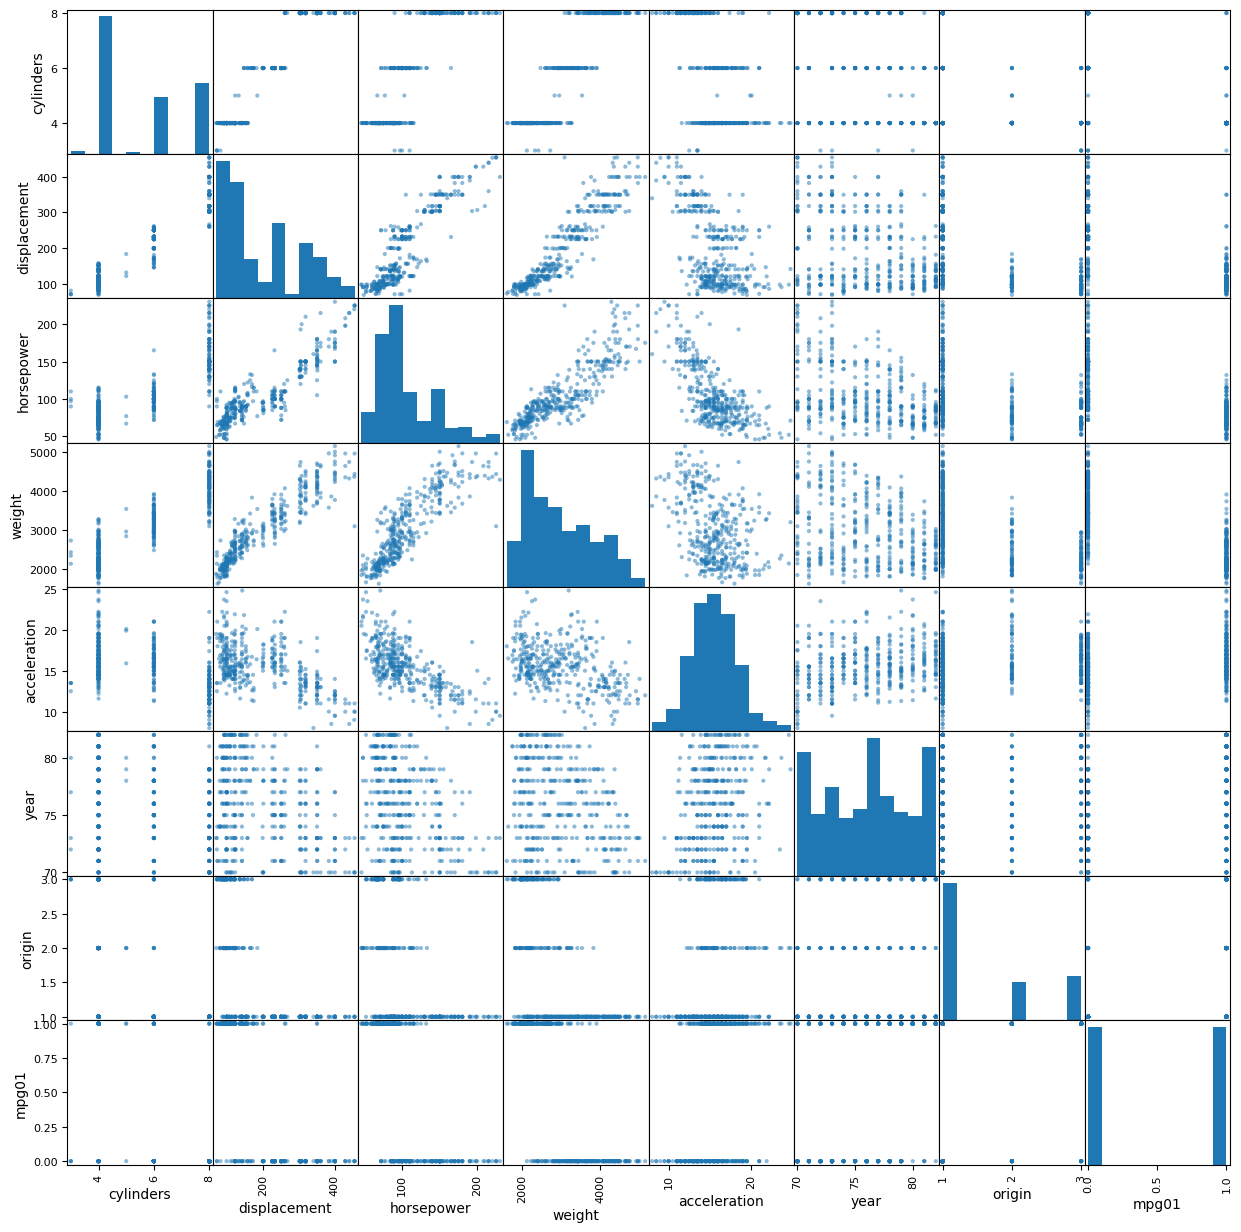

In [35]:
pd.plotting.scatter_matrix(Auto, figsize=(15,15));

<Axes: >

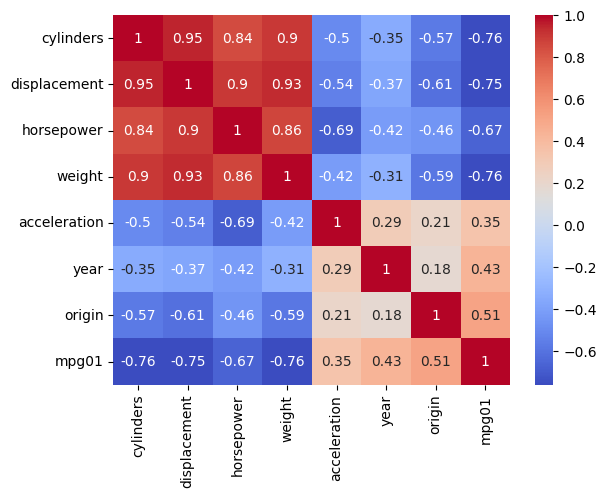

In [36]:
sns.heatmap(Auto.corr(), annot=Auto.corr(), cmap='coolwarm')

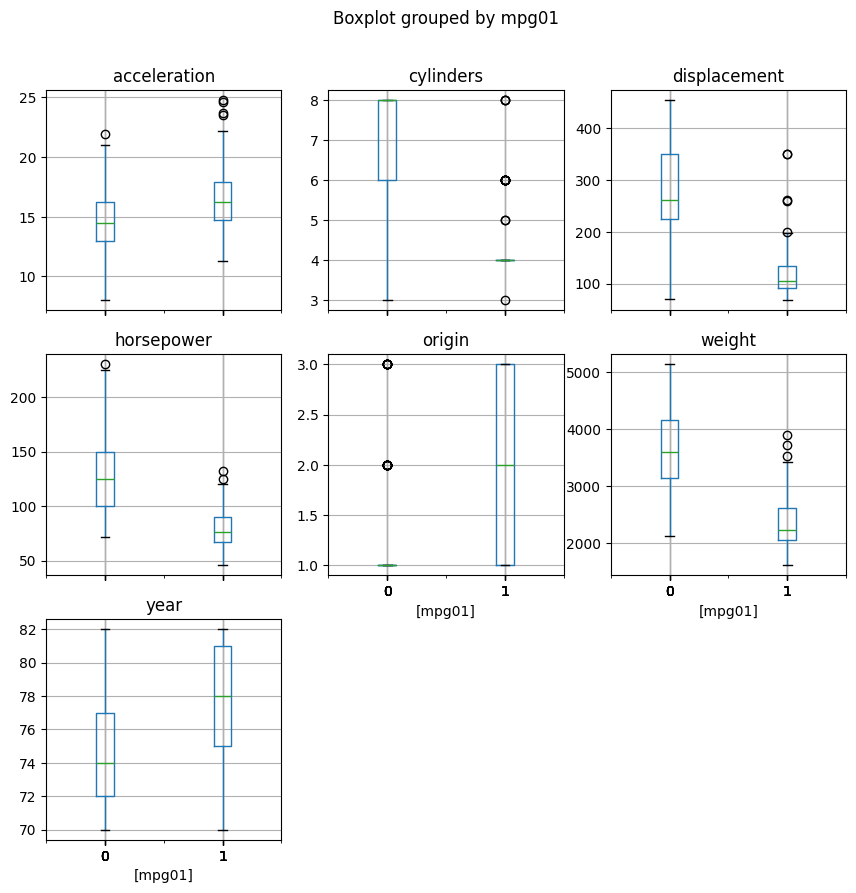

In [37]:
Auto.boxplot(by='mpg01', sharey=False, figsize=(10,10));

Displacement, horspower, weight, and cylinders are the strongest predictors
Year, origin, and acceleration might be less significant, but still provide meaningful insight

### c) Train-Test Split

In [38]:
# Keeping 'displacement', 'horsepower', 'weight', and 'cylinders'
to_drop = Auto.columns.drop(['displacement', 'horsepower', 'weight', 'cylinders'])
X_train, X_test, y_train, y_test = train_test_split(Auto.drop(columns=to_drop),
                                                    Auto['mpg01'],
                                                    train_size=0.8,
                                                    random_state=1)

X_train, X_test, y_train, y_test

(                                  cylinders  displacement  horsepower  weight
 name                                                                         
 plymouth reliant                          4         135.0          84    2490
 dodge aspen                               6         225.0         110    3620
 audi fox                                  4          98.0          83    2219
 datsun 310                                4          86.0          65    2019
 volkswagen jetta                          4         105.0          74    2190
 ...                                     ...           ...         ...     ...
 toyota corolla                            4          97.0          75    2155
 amc concord                               6         232.0          90    3210
 chevrolet chevelle concours (sw)          8         307.0         130    4098
 chevrolet chevette                        4          98.0          63    2051
 chevrolet impala                          8        

### d-h) Modeling

In [39]:
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def fit_predict(model):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print('Test Error:', mean_squared_error(y_test, y_pred))

### d) LDA

In [40]:
fit_predict(LDA(store_covariance=True))

Test Error: 0.06329113924050633


### e) QDA

In [41]:
fit_predict(QDA(store_covariance=True))

Test Error: 0.0379746835443038


### f) Logistic Regression

In [42]:
# sm requires ModelSpec intercept
design = MS(X_train.columns)
X_train_i = design.fit_transform(X_train)
X_test_i = design.transform(X_test)

# Fit the model
lg = sm.GLM(y_train, X_train_i, sm.families.Binomial())
lg_r = lg.fit()

# Predict
y_pred = lg_r.predict(X_test_i)
y_pred[y_pred > 0.5] = 1
y_pred[y_pred <= 0.5] = 0

print('Test Error:', mean_squared_error(y_test, y_pred))

Test Error: 0.05063291139240506


### g) Naive Bayes

In [43]:
fit_predict(GaussianNB())

Test Error: 0.05063291139240506


### h) KNN

In [44]:
# k = 10 is the best
for k in [1, 5, 7, 8, 9, 10, 11, 15, 20, 100]:
  print('\nFor k =', k)
  fit_predict(KNeighborsClassifier(n_neighbors=k))


For k = 1
Test Error: 0.0759493670886076

For k = 5
Test Error: 0.0759493670886076

For k = 7
Test Error: 0.06329113924050633

For k = 8
Test Error: 0.06329113924050633

For k = 9
Test Error: 0.0379746835443038

For k = 10
Test Error: 0.0379746835443038

For k = 11
Test Error: 0.05063291139240506

For k = 15
Test Error: 0.05063291139240506

For k = 20
Test Error: 0.05063291139240506

For k = 100
Test Error: 0.05063291139240506


## 15. Power Functions

### a) 2^3

In [45]:
def Power():
  print(2**3)

Power()

8


### b) Print x^a

In [47]:
def Power2(x, a):
  print(x**a)

Power2(3, 8)

6561


### c) 10^3, 8^17, 131^3

In [48]:
Power2(10,3)
Power2(8,17)
Power2(131,3)

1000
2251799813685248
2248091


### d) Return x^a

In [50]:
def Power3(x, a):
  result = x**a
  return result

print(Power3(2,3))

8


### e) Plotting x^2

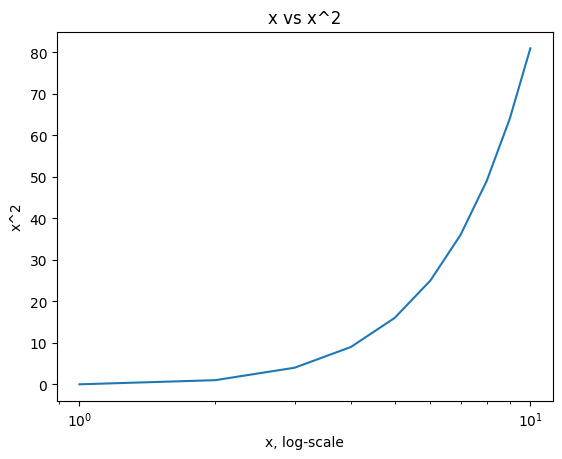

In [85]:
# Basic
# y = np.zeros(10)
# for n in range(10):
#   y[n] = Power3(n, 2)

# More elegant
y = np.array([Power3(n, 2) for n in range(10)])

# Graphing
plt.plot(np.arange(1,11), y)

# plt.yscale('log')
plt.xscale('log')

plt.title('x vs x^2')
plt.xlabel('x, log-scale')
plt.ylabel('x^2')

plt.show()

### f) Plot Power

In [92]:
def PlotPower(x, a):
  y = np.array([Power3(n, a) for n in x])

  plt.plot(x, y)
  plt.title('x vs x^a')
  plt.xlabel('x')
  plt.ylabel('x^a')

  plt.show()

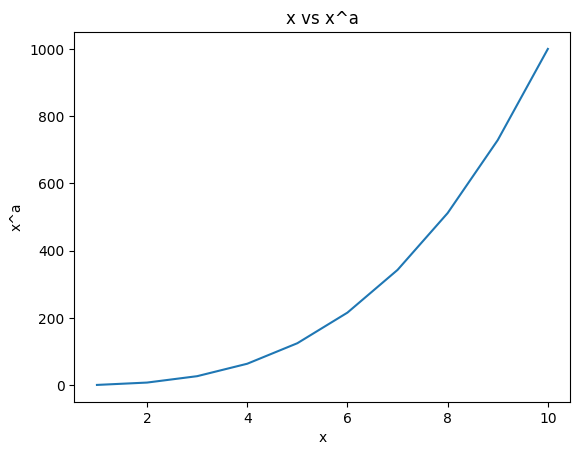

In [93]:
PlotPower(np.arange(1, 11), 3)

## 16. Boston Dataset